# Exercise 3: Spectrum Fitting

In [3]:
# write a program that parses spectrum.txt DONE
#Fit a low-order polynomial to the background of the spectrum (ignoring the emission line peak);
#Fit a Gaussian to the emission line peak; and
#Extract all the relevant parameters (and uncertainties) from your Gaussian and polynomial functions

In [4]:
#As a guideline, structure your code so that it can be run from a terminal with

#$ python scriptname.py spectrum.txt

In [5]:
#importing necessary libraries
from scipy.optimize import curve_fit
import numpy as np 
import matplotlib.pyplot as plt

### Creating a Function to read the spectrum data

In [6]:
def parse_spectrum(filename):
    header = {}
    wavelengths = []
    fluxes = []
    current_key = None

    with open(filename, "r") as f:
        for line in f:
            line = line.strip()

            if line.startswith("#"): # header key line
                key = line[1:].strip()
                if key not in ("DATA", ""):
                    current_key = key
                continue

            if current_key:    # header value line
                header[current_key] = line
                current_key = None
                continue

            if line.startswith("WAVELENGTH"): # skipping column header
                continue

            if "," in line:  # rows with data
                try:
                    w, fl = map(float, line.split(","))
                    wavelengths.append(w)
                    fluxes.append(fl)
                except ValueError:
                    pass

    return header, np.array(wavelengths), np.array(fluxes)


In [7]:
filename = 'spectrum.txt'
header, wavelengths, fluxes = parse_spectrum(filename)
header, wavelengths, fluxes

({'OBS_DATE': '2006-04-09T04:58:42.323',
  'TELESCOPE': 'ESO-VLT-U2',
  'INSTRUMENT': 'UVES',
  'TARGET': '2MASS J13004255+1912354',
  'EXPOSURE TIME (SEC)': '3899.9993',
  'PROGRAMME ID': '077.C-0449(A)',
  'RIGHT ASCENSION': '13:00:42.2',
  'DECLINATION': '19:12:26.8',
  'DETECTOR GAIN': '0.63',
  'WAVELENGTH UNIT': 'Angstrom',
  'FLUX UNIT': 'ADU',
  'COMMENT': "Adapted from the FITS (Flexible Image Transport System) format is defined in 'Astronomy"},
 array([6641.0923, 6641.1314, 6641.1705, ..., 6753.4896, 6753.5287,
        6753.5678], shape=(2878,)),
 array([39.7659, 37.1318, 32.4724, ..., 55.0867, 39.979 , 59.2691],
       shape=(2878,)))

In [ ]:
def polynomial(x, *params):
    """ a polynomial function to use for modelling spectra background"""
    return np.polyval(params, x) 

In [ ]:
def gaussian(x, amp, mu, sig, c_0):
    """
    A Gaussian function to use for fitting data using curvefit.
    x = x
    amp = amplitude
    mu = centre peak position
    sig = standard deviation
    c_0 = baseline
    """
    y = c_0 + amp * np.exp(-(x - mu)**2/(2*sig**2))
    return y 

In [12]:
%%writefile spectrum_fitter.py

from scipy.optimize import curve_fit
import numpy as np 
import matplotlib.pyplot as plt

# file = "/Users/caleicat/Downloads/spectrum.txt" #uploading file to python
# data = np.loadtxt(file, delimiter=',', skiprows = 27) #skipping header data and loading data from file

# wavelengths = data[:,0] #unpacking data
# fluxes = data[:,1]

# defining function to use w/ curve_fit for fitting background

filename = 'spectrum.txt'

def parse_spectrum(filename):
    header = {}
    wavelengths = []
    fluxes = []
    current_key = None

    with open(filename, "r") as f:
        for line in f:
            line = line.strip()

            if line.startswith("#"): # header key line
                key = line[1:].strip()
                if key not in ("DATA", ""):
                    current_key = key
                continue

            if current_key:    # header value line
                header[current_key] = line
                current_key = None
                continue

            if line.startswith("WAVELENGTH"): # skipping column header
                continue

            if "," in line:  # rows with data
                try:
                    w, fl = map(float, line.split(","))
                    wavelengths.append(w)
                    fluxes.append(fl)
                except ValueError:
                    pass

    return header, np.array(wavelengths), np.array(fluxes)


header, wavelengths, fluxes = parse_spectrum(filename)


def polynomial(x, *params):
    """ a polynomial function to use for modelling spectra background"""
    return np.polyval(params, x) 

#also going to define Gaussian here for later 

def gaussian(x, amp, mu, sig, c_0):
    """
    A Gaussian function to use for fitting data using curvefit.
    x = x
    amp = amplitude
    mu = centre peak position
    sig = standard deviation
    c_0 = baseline
    """
    y = c_0 + amp * np.exp(-(x - mu)**2/(2*sig**2))
    return y 

# fitting background
#need to mask peak for fitting - going to use sigma clipping

def fit_function_bkg(w, f, deg, sig, max_iter, plot):
    """
    Fit a polynomial to background of spectra using sigma clipping, 
    plots the result, and prints parameters. 
    --------------------------------------------------------------
    w = wavelengths in Angstrom 
    f = flux 
    sig = adjust number of deviations / range of sigma clipping
    deg = desired degree of polynomial 
    max_iter = max number of iterations 
    
    """
    mask = np.ones_like(f, dtype=bool) #creating a mask of fluxes
    p0 = np.ones(deg + 1) # guess parameters for curve_fit

    for val in range(max_iter):
        popt, pcov = curve_fit(polynomial, w[mask], f[mask], p0=p0)
        p0 = popt # update guess for next iteration 

        fit = polynomial(w, *popt)

        residuals = f - fit

        std = np.std(residuals[mask])

        mask_sigclip = residuals >= (-sig * std)

        mask = mask_sigclip

    popt_bkg, pcov_final = curve_fit(polynomial, w[mask], f[mask], p0=p0)
    final_bkg = polynomial(w, *popt_bkg)

    if plot == True:
        plt.scatter(w, f, label="Data")
        plt.plot(w, final_bkg, linewidth=2, color='orange', label="Background Fit")
        plt.legend()
        plt.grid(True)
        plt.xlabel("Wavelength (Angstrom)")
        plt.ylabel("Flux")
        plt.title("Background Fitting Result")
    print(f"The parameters for the background fit are: {popt_bkg}")
    return popt_bkg, pcov_final, final_bkg 

popt_bkg, pcov_bkg, final_bkg = fit_function_bkg(wavelengths, fluxes, 5, 2, 5, plot=True)

# fitting peak

def fit_spectra(w, f, deg, sig, max_iter, plot):
    """
    A function that fits spectral peaks and background.
    This function relies on the "fit_function_bkg" function.
    ____________________________________________________
    w = wavelength data 
    f = flux data 
    deg = polynomial degree for background fit 
    sig = number of standard deviations for sigma clipping for background fit 
    max_iter = max number of iterations for background fitting 
    """
    popt_bkg, pcov_bkg, final_bkg = fit_function_bkg(w, f, deg, sig, max_iter, plot=False)
    
    bkg_subtracted = f - final_bkg

    #need to give guesses for initial parameters for a good fit - tried first time and got a straight line fit
    amp_guess = np.max(bkg_subtracted) # guessing amplitude as max value
    mu_guess = w[np.argmax(bkg_subtracted)] # guess for peak location where max is
    std_guess = np.std(f)
    c_0_guess = 0

    p0 = [amp_guess, mu_guess, std_guess, c_0_guess]

    popt, pcov = curve_fit(gaussian, w, bkg_subtracted, p0=p0)
    if plot == True:
        plt.plot(w, f, label="Data")
        plt.plot(w, gaussian(wavelengths, *popt) + np.median(final_bkg), color = "red", label="Gaussian Result")
        plt.plot(w, final_bkg, color="orange", label="Background Fit Result")
        plt.xlabel(f"Wavelength (Angstrom)")
        plt.ylabel(r"Flux (erg s^{-1} cm^{-2})")
        plt.title("Spectra Fit Results")
        plt.grid(True)
        plt.legend()
    print(f"The parameters for the Gaussian fit are: {popt}")
    print(f"The peak location is at {popt[1]} angstrom.")

fit_spectra(wavelengths, fluxes, 5, 2, 5, plot=True)

Overwriting spectrum_fitter.py


The parameters for the background fit are: [ 1.86496856e-10 -4.76208694e-06  4.39672636e-02 -1.62040114e+02
  1.00243901e+05  4.56818668e+08]
The parameters for the background fit are: [ 1.86496856e-10 -4.76208694e-06  4.39672636e-02 -1.62040114e+02
  1.00243901e+05  4.56818668e+08]
The parameters for the Gaussian fit are: [ 3.10366191e+01  6.68689814e+03 -2.20983712e+00 -1.86378842e+00]
The peak location is at 6686.8981361141305 angstrom.


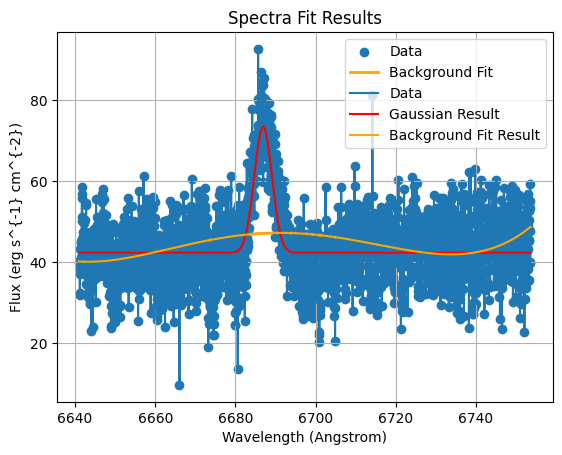

In [13]:
%run spectrum_fitter.py